In [1]:
import pandas as pd

# Load the dataset
data = pd.read_csv("/content/sales-of-shampoo-over-a-three-ye.csv")

print("Dataset loaded successfully!")
print(data.head())

Dataset loaded successfully!
   Month  Sales of shampoo over a three year period
0  1-Jan                                      266.0
1  1-Feb                                      145.9
2  1-Mar                                      183.1
3  1-Apr                                      119.3
4  1-May                                      180.3


In [2]:
# Check the dataset structure

print("Dataset shape:", data.shape)

print("\nColumn names:")
print(data.columns)

print("\nData types:")
print(data.dtypes)

print("\nLast 5 rows:")
print(data.tail())

Dataset shape: (36, 2)

Column names:
Index(['Month', 'Sales of shampoo over a three year period'], dtype='object')

Data types:
Month                                         object
Sales of shampoo over a three year period    float64
dtype: object

Last 5 rows:
    Month  Sales of shampoo over a three year period
31  3-Aug                                      407.6
32  3-Sep                                      682.0
33  3-Oct                                      475.3
34  3-Nov                                      581.3
35  3-Dec                                      646.9


In [4]:
# Convert Month into a proper date

data["Date"] = pd.to_datetime(
    data["Month"].str.extract(r"(\d+)-(\w+)")[0] + "-" +
    data["Month"].str.extract(r"(\d+)-(\w+)")[1],
    format="%m-%b",
    errors="coerce"
)

print("Date column created successfully!")
print(data[["Month", "Date"]].head())

Date column created successfully!
   Month       Date
0  1-Jan 1900-01-01
1  1-Feb 1900-02-01
2  1-Mar 1900-03-01
3  1-Apr 1900-04-01
4  1-May 1900-05-01


In [5]:
# Create a sequential month number and a readable date label

data["Year"] = data["Month"].str.extract(r"(\d+)-")[0].astype(int)
data["Month_Name"] = data["Month"].str.extract(r"-(\w+)")[0]

# Create a sequential month index: 1 to 36
data["Month_Index"] = range(1, len(data) + 1)

print("Time columns created successfully!")
print(data[["Month", "Year", "Month_Name", "Month_Index"]].head())
print("\nLast 5 rows:")
print(data[["Month", "Year", "Month_Name", "Month_Index"]].tail())

Time columns created successfully!
   Month  Year Month_Name  Month_Index
0  1-Jan     1        Jan            1
1  1-Feb     1        Feb            2
2  1-Mar     1        Mar            3
3  1-Apr     1        Apr            4
4  1-May     1        May            5

Last 5 rows:
    Month  Year Month_Name  Month_Index
31  3-Aug     3        Aug           32
32  3-Sep     3        Sep           33
33  3-Oct     3        Oct           34
34  3-Nov     3        Nov           35
35  3-Dec     3        Dec           36


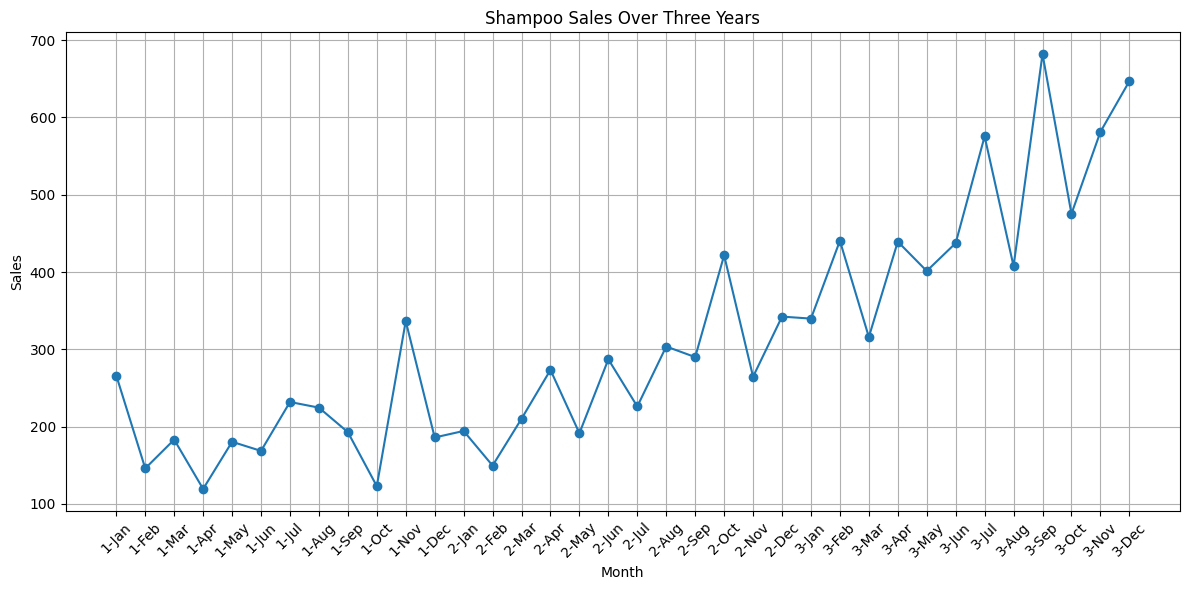

Line chart saved as sales_over_three_years.png


In [6]:
import matplotlib.pyplot as plt

# Create line chart for sales over time

plt.figure(figsize=(12, 6))

plt.plot(
    data["Month_Index"],
    data["Sales of shampoo over a three year period"],
    marker="o"
)

plt.title("Shampoo Sales Over Three Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(
    data["Month_Index"],
    data["Month"],
    rotation=45
)
plt.grid(True)
plt.tight_layout()

plt.savefig("sales_over_three_years.png", dpi=300)
plt.show()

print("Line chart saved as sales_over_three_years.png")

In [7]:
# Calculate average sales for each month across the three years

monthly_sales = data.groupby("Month_Name")[
    "Sales of shampoo over a three year period"
].mean()

print("Average Sales by Month:")
print(monthly_sales)

Average Sales by Month:
Month_Name
Apr    277.300000
Aug    311.900000
Dec    391.700000
Feb    245.266667
Jan    266.666667
Jul    344.433333
Jun    297.633333
Mar    236.366667
May    257.666667
Nov    394.100000
Oct    339.933333
Sep    388.233333
Name: Sales of shampoo over a three year period, dtype: float64


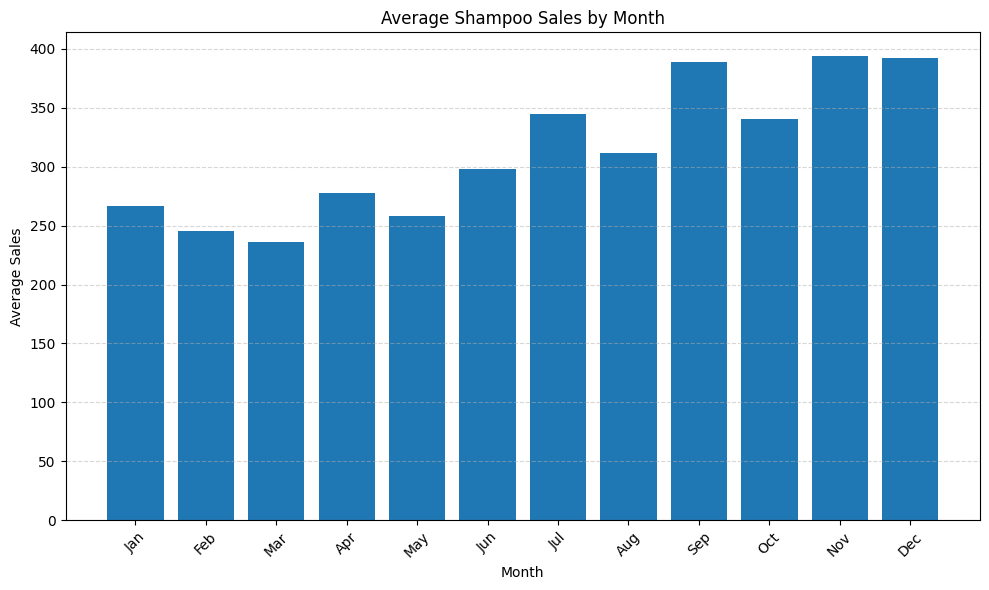

Bar chart saved as average_monthly_sales.png


In [8]:
# Arrange months in calendar order

month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_sales = monthly_sales.reindex(month_order)

# Create bar chart

plt.figure(figsize=(10, 6))

plt.bar(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Average Shampoo Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("average_monthly_sales.png", dpi=300)
plt.show()

print("Bar chart saved as average_monthly_sales.png")

Total Sales by Year:
Year
1    2357.5
2    3153.5
3    5742.6
Name: Sales of shampoo over a three year period, dtype: float64


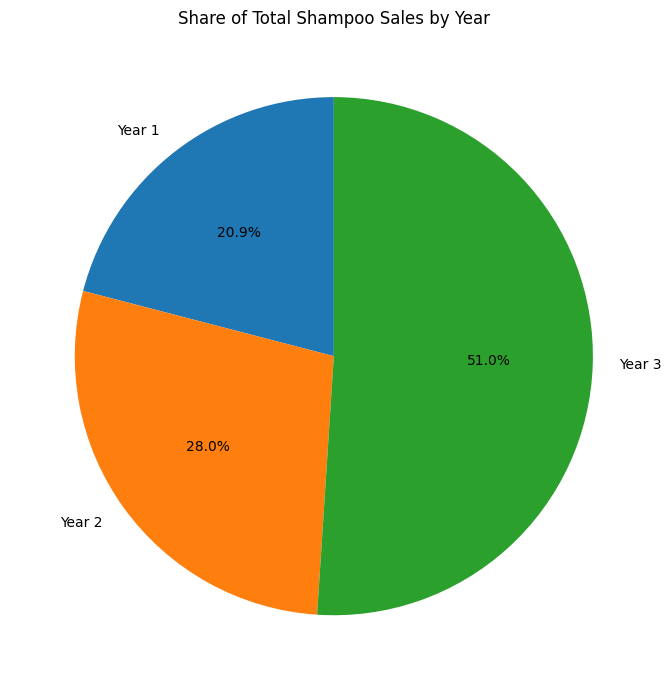

Pie chart saved as sales_share_by_year.png


In [9]:
# Calculate total sales for each year

yearly_sales = data.groupby("Year")[
    "Sales of shampoo over a three year period"
].sum()

print("Total Sales by Year:")
print(yearly_sales)

# Create pie chart

plt.figure(figsize=(7, 7))

plt.pie(
    yearly_sales.values,
    labels=[f"Year {year}" for year in yearly_sales.index],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Share of Total Shampoo Sales by Year")
plt.tight_layout()

plt.savefig("sales_share_by_year.png", dpi=300)
plt.show()

print("Pie chart saved as sales_share_by_year.png")

In [10]:
# Short summary and chart explanation

print("Project Summary")
print("-" * 50)

print("1. The line chart shows monthly shampoo sales across three years.")
print("2. The bar chart compares average sales for each month.")
print("3. The pie chart shows each year's share of total sales.")
print("4. Sales increased overall from Year 1 to Year 3, although monthly values fluctuate.")

print("\nChart Choices and Formatting")
print("-" * 50)

print("Line chart: Used because the data represents sales over time.")
print("Bar chart: Used to compare average sales across months.")
print("Pie chart: Used to show each year's share of total sales.")
print("Labels and titles were added to make the charts easier to understand.")
print("The x-axis labels were rotated where necessary for readability.")
print("Grid lines were added to improve visual comparison.")

Project Summary
--------------------------------------------------
1. The line chart shows monthly shampoo sales across three years.
2. The bar chart compares average sales for each month.
3. The pie chart shows each year's share of total sales.
4. Sales increased overall from Year 1 to Year 3, although monthly values fluctuate.

Chart Choices and Formatting
--------------------------------------------------
Line chart: Used because the data represents sales over time.
Bar chart: Used to compare average sales across months.
Pie chart: Used to show each year's share of total sales.
Labels and titles were added to make the charts easier to understand.
The x-axis labels were rotated where necessary for readability.
Grid lines were added to improve visual comparison.


In [11]:
# Create quarter information

data["Quarter"] = "Q" + ((data["Month_Index"] - 1) // 3 + 1).astype(str)

# Include the year so that each year's quarter is separate
data["Year_Quarter"] = (
    "Year " + data["Year"].astype(str) + " - " + data["Quarter"]
)

# Calculate total sales for each year-quarter
quarterly_sales = data.groupby("Year_Quarter")[
    "Sales of shampoo over a three year period"
].sum()

print("Quarterly Total Sales:")
print(quarterly_sales)

Quarterly Total Sales:
Year_Quarter
Year 1 - Q1      595.0
Year 1 - Q2      468.1
Year 1 - Q3      649.1
Year 1 - Q4      645.3
Year 2 - Q5      553.9
Year 2 - Q6      751.7
Year 2 - Q7      819.5
Year 2 - Q8     1028.4
Year 3 - Q10    1278.0
Year 3 - Q11    1665.1
Year 3 - Q12    1703.5
Year 3 - Q9     1096.0
Name: Sales of shampoo over a three year period, dtype: float64


In [12]:
# Correct quarter calculation: Q1 to Q4 for each year

data["Quarter"] = "Q" + (
    ((data["Month_Index"] - 1) % 12) // 3 + 1
).astype(str)

data["Year_Quarter"] = (
    "Year " + data["Year"].astype(str) + " - " + data["Quarter"]
)

# Calculate total sales for each year-quarter
quarterly_sales = data.groupby("Year_Quarter")[
    "Sales of shampoo over a three year period"
].sum()

print("Corrected Quarterly Total Sales:")
print(quarterly_sales)

Corrected Quarterly Total Sales:
Year_Quarter
Year 1 - Q1     595.0
Year 1 - Q2     468.1
Year 1 - Q3     649.1
Year 1 - Q4     645.3
Year 2 - Q1     553.9
Year 2 - Q2     751.7
Year 2 - Q3     819.5
Year 2 - Q4    1028.4
Year 3 - Q1    1096.0
Year 3 - Q2    1278.0
Year 3 - Q3    1665.1
Year 3 - Q4    1703.5
Name: Sales of shampoo over a three year period, dtype: float64


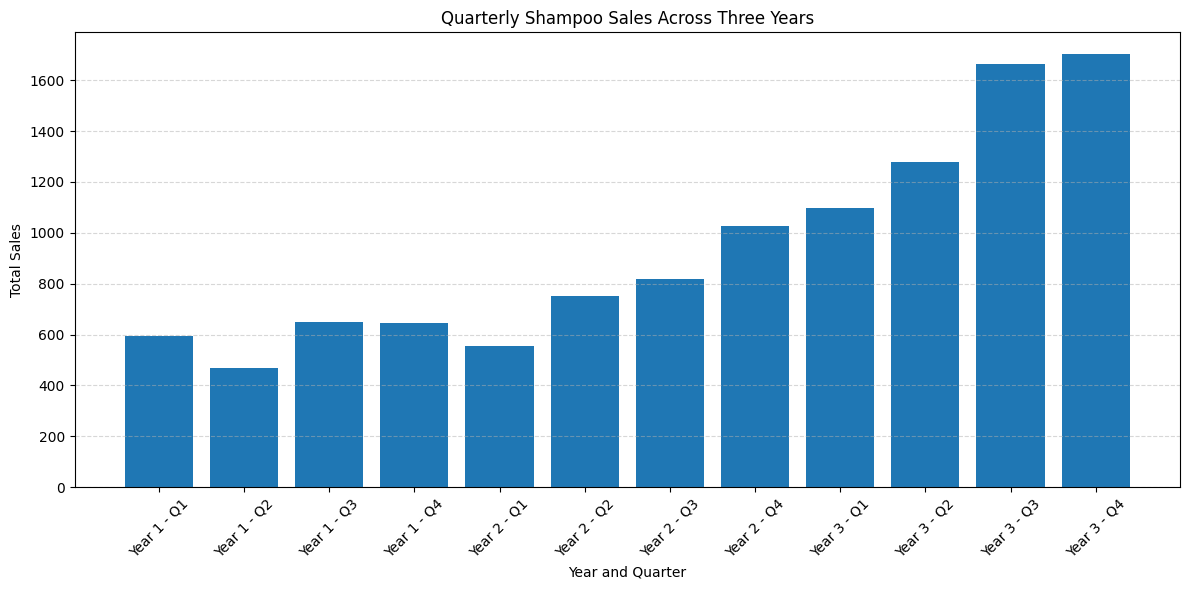

Quarterly chart saved as quarterly_sales.png


In [13]:
# Create quarterly sales bar chart

plt.figure(figsize=(12, 6))

plt.bar(
    quarterly_sales.index,
    quarterly_sales.values
)

plt.title("Quarterly Shampoo Sales Across Three Years")
plt.xlabel("Year and Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("quarterly_sales.png", dpi=300)
plt.show()

print("Quarterly chart saved as quarterly_sales.png")

In [14]:
# Final Project 1 summary

total_sales = data["Sales of shampoo over a three year period"].sum()
average_sales = data["Sales of shampoo over a three year period"].mean()
highest_month = data.loc[
    data["Sales of shampoo over a three year period"].idxmax()
]

summary = pd.DataFrame({
    "Metric": [
        "Number of records",
        "Total sales",
        "Average monthly sales",
        "Highest sales month",
        "Highest monthly sales"
    ],
    "Value": [
        len(data),
        round(total_sales, 2),
        round(average_sales, 2),
        highest_month["Month"],
        highest_month["Sales of shampoo over a three year period"]
    ]
})

print("Final Project Summary:")
print(summary.to_string(index=False))

Final Project Summary:
               Metric    Value
    Number of records       36
          Total sales  11253.6
Average monthly sales    312.6
  Highest sales month    3-Sep
Highest monthly sales    682.0
